# Exploratory Data Analysis (EDA) On Retail Sales
## Objective:
Performing a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

## Importing required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

## Loading the Dataset

In [2]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Initial Dataset Inspection

In [3]:
print("Dataset shape:",df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Dataset shape: (1000, 9)

Column names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


### Observation
-The dataset contains thousand rows and nine columns.
-The dataset includes customer information , sales information, transaction details, product categories.
-The data types appear appropriate for further analysis, although the **Date** column will be converted to datetime format in a later step.

In [4]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Observation
-**No** missing values found were in  the dataset. This indicates that no missing values treatment is needed for our dataset.

## Descriptive Statistics

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
print("Mean:")
df.mean(numeric_only=True)

Mean:


Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [7]:
print("Median:")
df.median(numeric_only=True)

Median:


Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [8]:
print("Mode:")
df.mode(numeric_only=True)

Mode:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [9]:
print("Standard Deviation")
df.std(numeric_only=True)

Standard Deviation


Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

### Observation
- The descriptive statistics provide an overview of the numerical variables in the dataset.
- The mean and median help understand the central tendency of customer age, quantity purchased, price per unit, and total transaction amount.
- The standard deviation indicates the variability in sales and customer purchasing behaviour.
- These statistics provide a foundation for deeper exploratory data analysis.

## Time Series Analysis

In [10]:
df['Date']=pd.to_datetime(df['Date'])
df['Date'].head()

0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]

In [11]:
df['Month']=df['Date'].dt.to_period('M')

In [12]:
Monthly_sales=df.groupby('Month')['Total Amount'].sum()
Monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

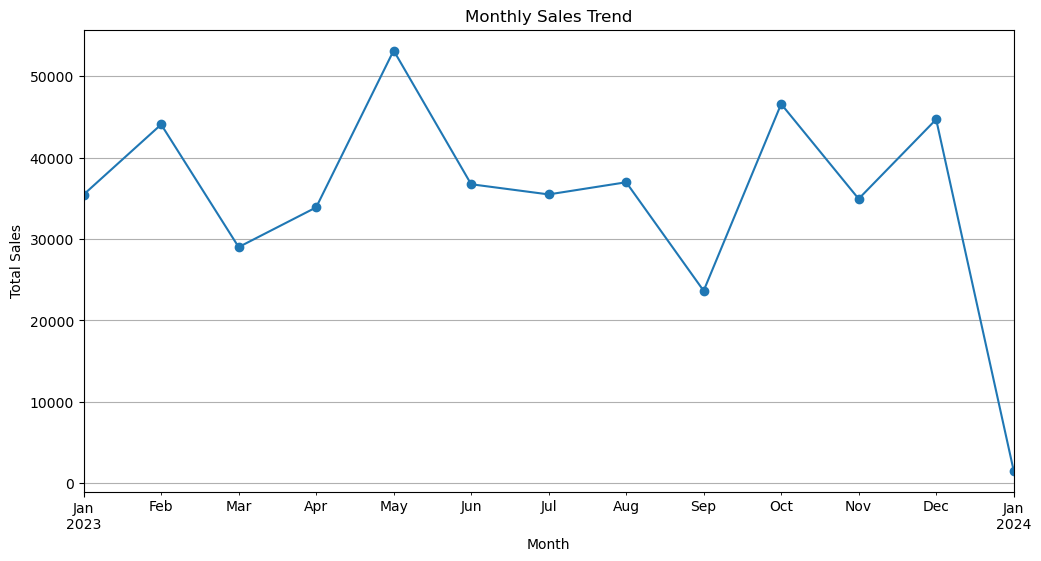

In [13]:
plt.figure(figsize=(12,6))
Monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Observation
- The monthly sales trend shows that the **highest sales** occurred in **May**.
- The **lowest sales** were recorded in **January 2024**.
- In **2023**, the lowest sales occurred during **September**.
- Sales remained relatively **stable** during **April, June, July, and November**.
- The observed sales pattern indicates seasonal fluctuations, suggesting that customer purchasing behavior varies throughout the year.

## Quarterly Sales Trend

In [14]:
df['Quarter']=df['Date'].dt.to_period('Q')

In [15]:
Quarterly_sales=df.groupby('Quarter')['Total Amount'].sum()
Quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

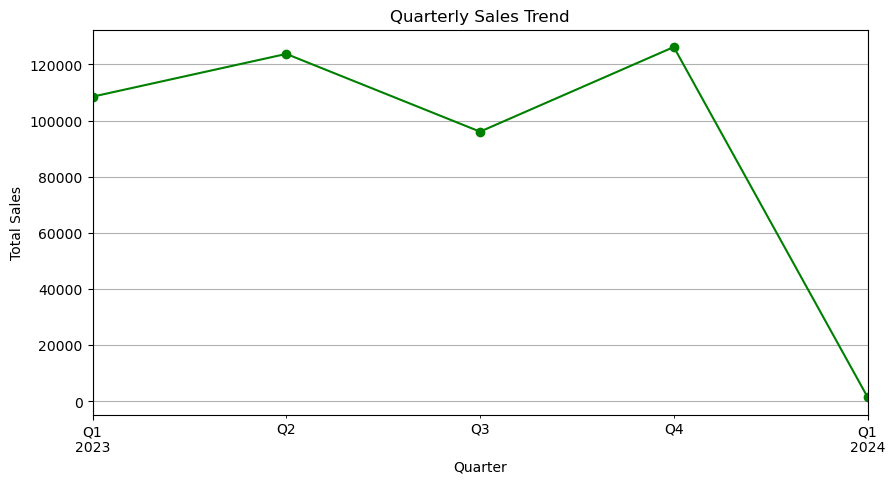

In [16]:
plt.figure(figsize=(10,5))
Quarterly_sales.plot(marker='o', color='green')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Observation
- The quarterly sales trend shows that **highest sales** occured during **second quarter**.
- During the **third quarter** the sales were **moderate**.
- From the **forth quarter** sales were started to **fall**.
- In **descending** we can rate 4 quarters as:**Q2>Q1>Q3>Q4**

## Customer Demographics Analysis

In [17]:
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

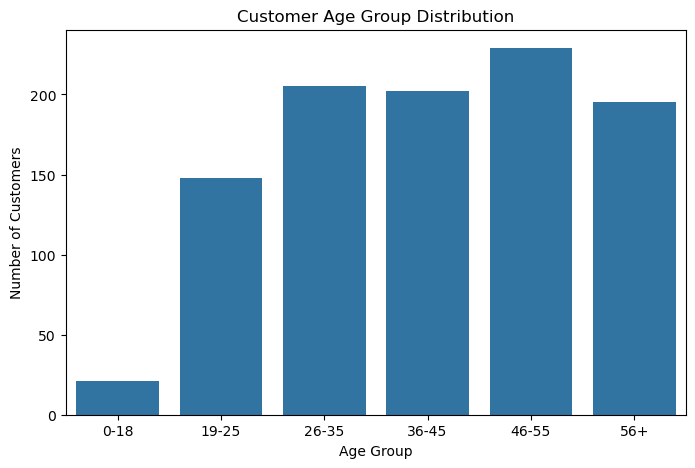

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age Group', data=df)
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

### Observation

- The majority of customers belong to the 46-55 years age group.
- The least represented age group is 0-18.
- The customer base is concentrated among 26-56 ages.

## Gender Distribution

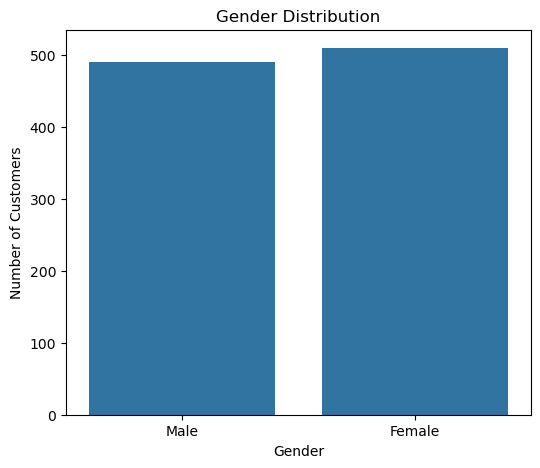

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender',data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Observation
- The dataset contains both male and female customers.
- The distribution between genders is almost **shared equally** with slightly more females.
- This indicates that the customer base is diverse across genders.

## Product Analysis

In [20]:
top_categories = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

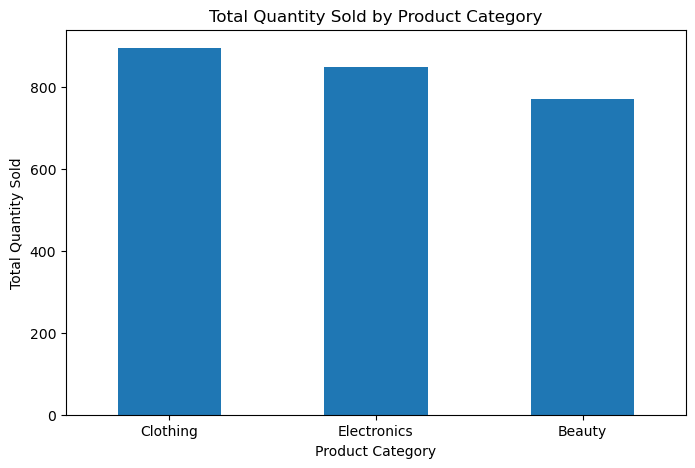

In [21]:
plt.figure(figsize=(8,5))
top_categories.plot(kind='bar')
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()

### Observation
- The highest-selling product category is **clothing**.
- The lowest-selling product category is **beauty**.
- Customers show greater demand for **clothing** and **electronic** products.

## Revenue by Product Category

In [22]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

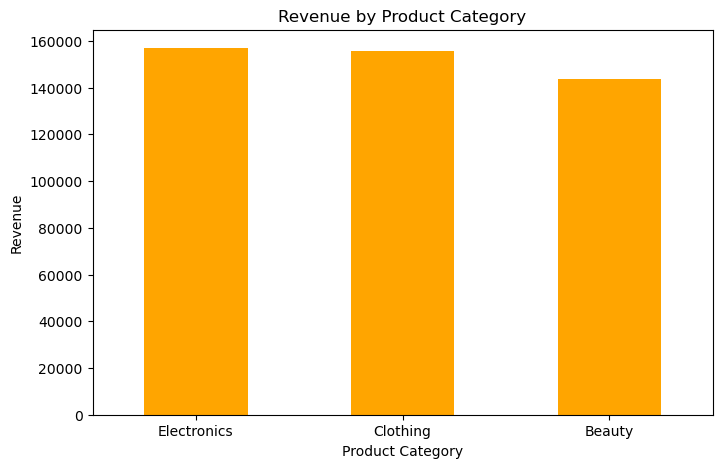

In [23]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='orange')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

### Observation

- The **electronics** category generated the highest revenue.
- The **beauty** category generated the lowest revenue.
- Revenue generation differs across product categories, indicating varying customer preferences.

## Correlation Heatmap

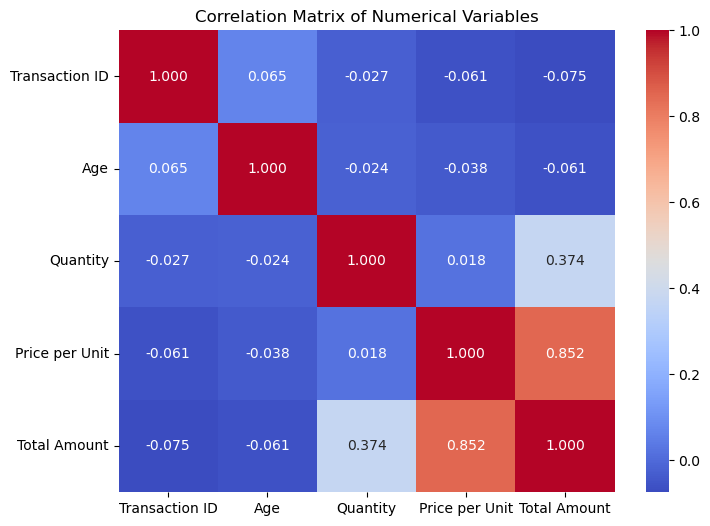

In [24]:
numerical_data = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observation
- **Correlation Heatmap** tells us the relations between numerical values in our dataset.
- **0.7 to 1.0 (Strong):** The points on a chart would form a very straight line. The connection is powerful.
- **0.3 to 0.7 (Moderate):** There is a clear trend, but there is also a lot of noise or variation in the data.
- **0.0 to 0.3 (Weak):** The relationship is barely visible and mostly random.

## Revenue By Age Group

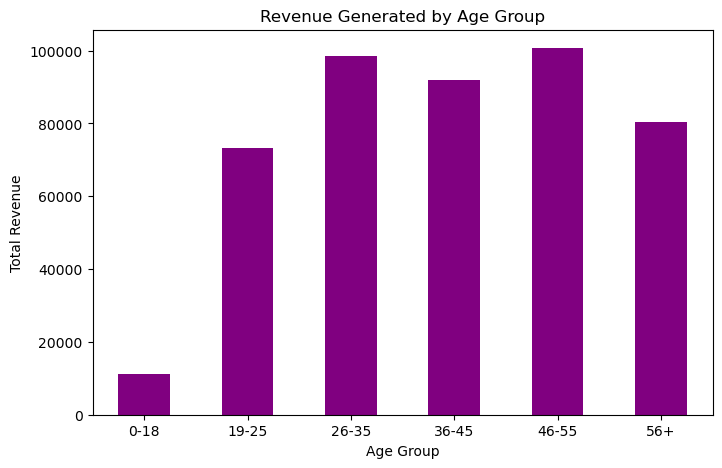

In [25]:
age_revenue = df.groupby('Age Group', observed=True)['Total Amount'].sum()
plt.figure(figsize=(8,5))
age_revenue.plot(kind='bar', color='purple')
plt.title('Revenue Generated by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### Observation
- The **46–55** age group generated the **highest revenue**.
- The **0–18** age group generated the **lowest revenue**.
- The results indicate that middle-aged customers contribute significantly more to total revenue than younger customers.
- This information can help businesses identify high-value customer segments for targeted marketing and promotional strategies.

## Business Recommendations
- Investigate the reasons behind low sales during certain months and introduce **discount campaigns** at the beginning of the year to increase customer purchases.
- Conduct loyalty programs for customers in the **46–55** age group, as they contribute the highest revenue.
- Stay up to date with emerging market trends and technologies and trends to improve customer experience and maximize revenue from the top-selling product categories.

## Conclusion
This Exploratory Data Analysis successfully examined retail sales data to identify customer purchasing behaviour, sales trends, and product performance. Various visualizations helped uncover seasonal patterns, demographic distributions, and category-wise revenue. The insights obtained from this analysis can support better business decisions related to inventory management, customer targeting, and sales strategy.